In [96]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import numpy as np

# Project
## World Wide Sales Analysis Of Video Games

In [97]:
df=pd.read_csv(r"c:\Users\user\Desktop\Kaggle Datasets\Video_Games_Sales_Cleaned.csv")

# Data Info 

In [98]:
df.shape

(18832, 8)

In [99]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18832 entries, 0 to 18831
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         18832 non-null  object 
 1   console       18832 non-null  object 
 2   genre         18832 non-null  object 
 3   publisher     18832 non-null  object 
 4   developer     18832 non-null  object 
 5   critic_score  18832 non-null  float64
 6   total_sales   18832 non-null  float64
 7   release_year  18832 non-null  float64
dtypes: float64(3), object(5)
memory usage: 1.1+ MB


In [100]:
df.head()

,title,console,genre,publisher,developer,critic_score,total_sales,release_year
0,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,20.32,2013.0
1,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.39,2014.0
2,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,16.15,2002.0
3,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,7.3,15.86,2013.0
4,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1,15.09,2015.0


# EDA & Visualization

In [101]:
df.isna().sum()
df.duplicated().sum()

np.int64(4)

In [102]:
numeric_cols = df.select_dtypes(include=np.number).columns

<Axes: title={'center': 'Count Of Different Genres'}, xlabel='genre'>

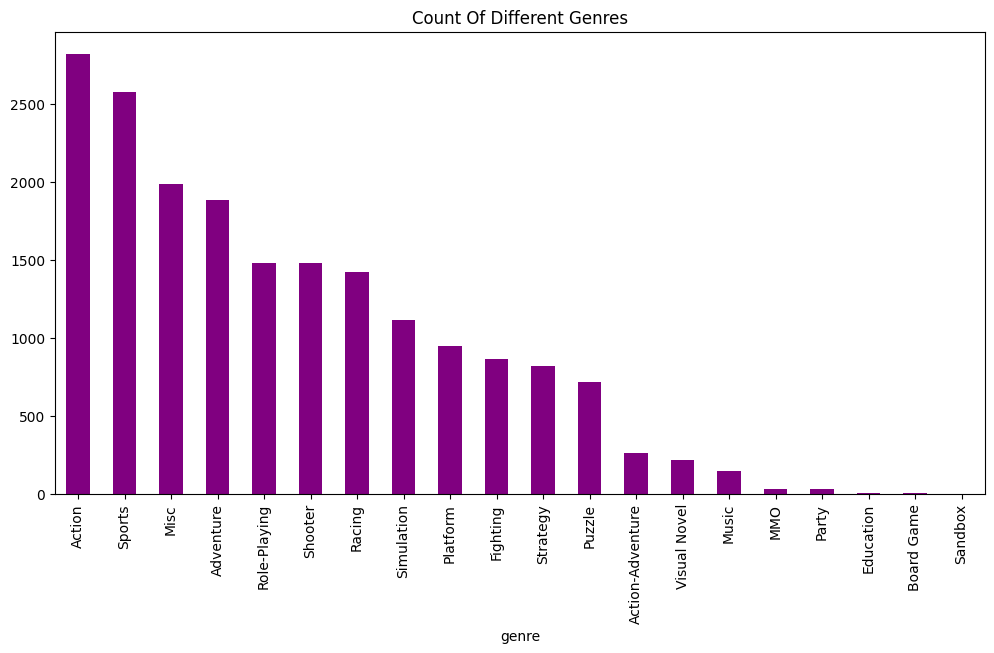

In [103]:
df["genre"].value_counts().plot(kind="bar",figsize=(12,6),title="Count Of Different Genres",color="purple")

In [104]:
df.head()

,title,console,genre,publisher,developer,critic_score,total_sales,release_year
0,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,20.32,2013.0
1,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.39,2014.0
2,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,16.15,2002.0
3,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,7.3,15.86,2013.0
4,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1,15.09,2015.0


In [105]:
df=df.rename(columns={"total_sales":"total_sales_of_copies_in_millions"})

In [106]:
df.head()

,title,console,genre,publisher,developer,critic_score,total_sales_of_copies_in_millions,release_year
0,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,20.32,2013.0
1,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.39,2014.0
2,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,16.15,2002.0
3,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,7.3,15.86,2013.0
4,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1,15.09,2015.0


In [113]:
top_games = (
    df.groupby("title")["total_sales_of_copies_in_millions"]
      .sum()
      .sort_values(ascending=False)
      .head(25)
).reset_index()

# Apply background gradient correctly
top_games.style.background_gradient(cmap="Reds")


,title,total_sales_of_copies_in_millions
0,Grand Theft Auto V,64.290000
1,Call of Duty: Black Ops,30.990000
2,Call of Duty: Modern Warfare 3,30.710000
3,Call of Duty: Black Ops II,29.590000
4,Call of Duty: Ghosts,28.800000
5,Call of Duty: Black Ops 3,26.720000
6,Call of Duty: Modern Warfare 2,25.020000
7,Minecraft,24.010000
8,Grand Theft Auto IV,22.530000
9,Call of Duty: Advanced Warfare,21.780000


In [115]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18832 entries, 0 to 18831
Data columns (total 8 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   title                              18832 non-null  object 
 1   console                            18832 non-null  object 
 2   genre                              18832 non-null  object 
 3   publisher                          18832 non-null  object 
 4   developer                          18832 non-null  object 
 5   critic_score                       18832 non-null  float64
 6   total_sales_of_copies_in_millions  18832 non-null  float64
 7   release_year                       18832 non-null  float64
dtypes: float64(3), object(5)
memory usage: 1.1+ MB


In [116]:
# 7. Top Developers by Total Sales
top_developers = df.groupby("developer")["total_sales_of_copies_in_millions"].sum().sort_values(ascending=False).head(10)
print("\nTop Developers:\n", top_developers)


Top Developers:
 developer
EA Canada            275.56
EA Tiburon           178.33
Ubisoft Montreal     172.96
Treyarch             150.19
Traveller's Tales    149.55
Infinity Ward        118.97
Rockstar North       116.91
Konami               109.42
Visual Concepts       97.61
Capcom                92.95
Name: total_sales_of_copies_in_millions, dtype: float64


In [117]:
# 8. Top Consoles by Sales
top_consoles = df.groupby("console")["total_sales_of_copies_in_millions"].sum().sort_values(ascending=False)
print("\nTop Consoles:\n", top_consoles.head(10))



Top Consoles:
 console
PS2     1025.38
X360     859.41
PS3      839.01
PS       546.21
PS4      539.92
Wii      458.92
DS       457.77
XOne     268.96
PSP      244.74
XB       232.05
Name: total_sales_of_copies_in_millions, dtype: float64


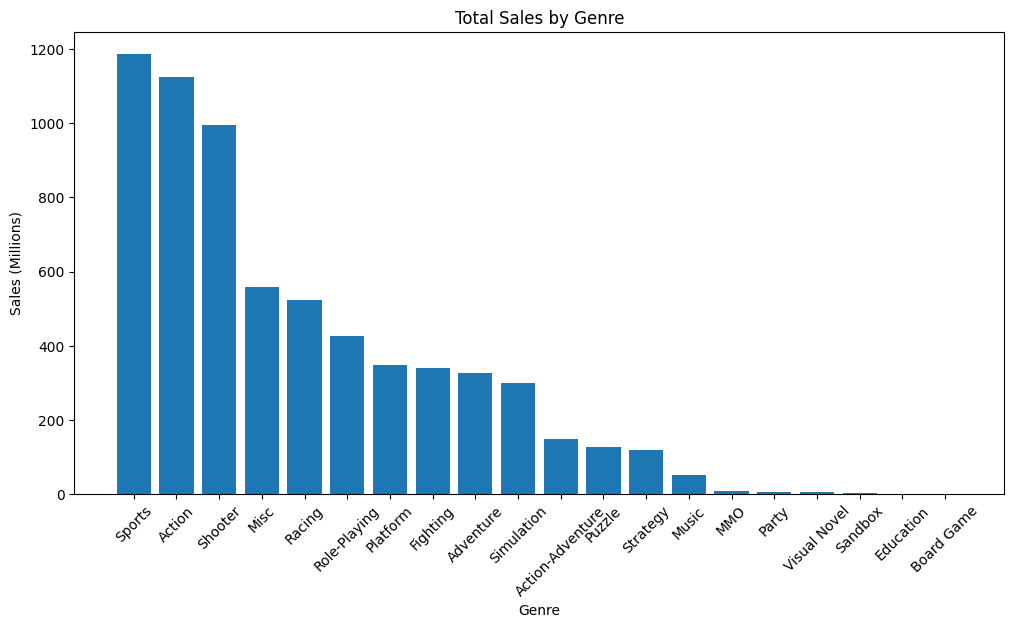

In [119]:
# 9. Sales by Genre
genre_sales = df.groupby("genre")["total_sales_of_copies_in_millions"].sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))
plt.bar(genre_sales.index, genre_sales.values)
plt.xticks(rotation=45)
plt.title("Total Sales by Genre")
plt.xlabel("Genre")
plt.ylabel("Sales (Millions)")
plt.show()


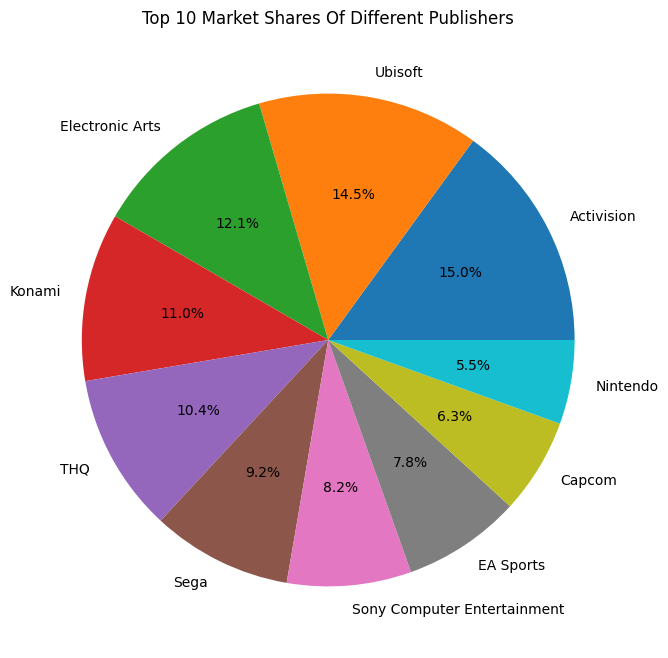

In [ ]:
# Market Shares Of Different Publishers
plt.figure(figsize=(8,8))
df["publisher"].value_counts().head(10).plot(kind="pie", autopct="%1.1f%%")
plt.title("Top 10 Market Shares Of Different Publishers")
plt.ylabel("")  # hides the default y-label
plt.show()


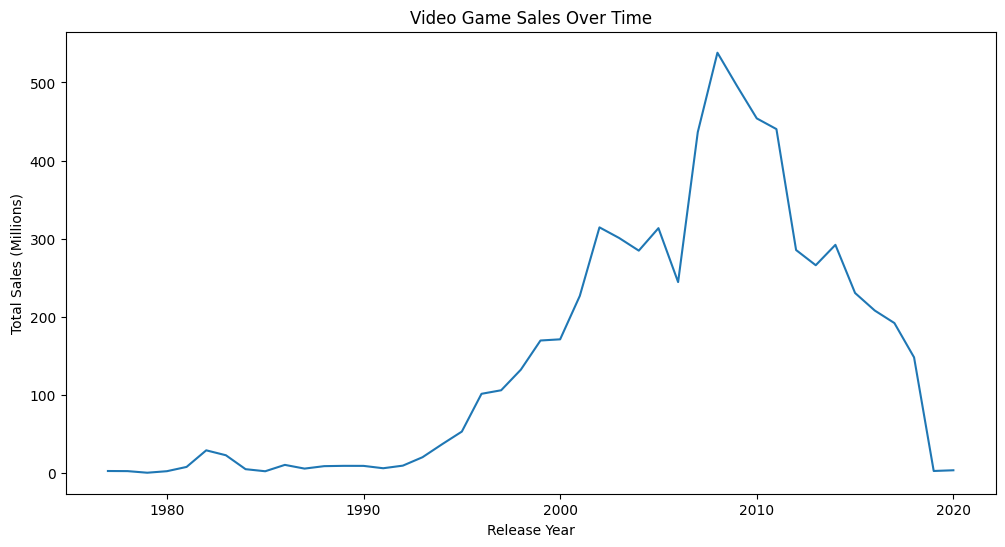

In [121]:
# 10. Year-wise Sales Trend
year_sales = df.groupby("release_year")["total_sales_of_copies_in_millions"].sum()

plt.figure(figsize=(12,6))
plt.plot(year_sales.index, year_sales.values)
plt.title("Video Game Sales Over Time")
plt.xlabel("Release Year")
plt.ylabel("Total Sales (Millions)")
plt.show()

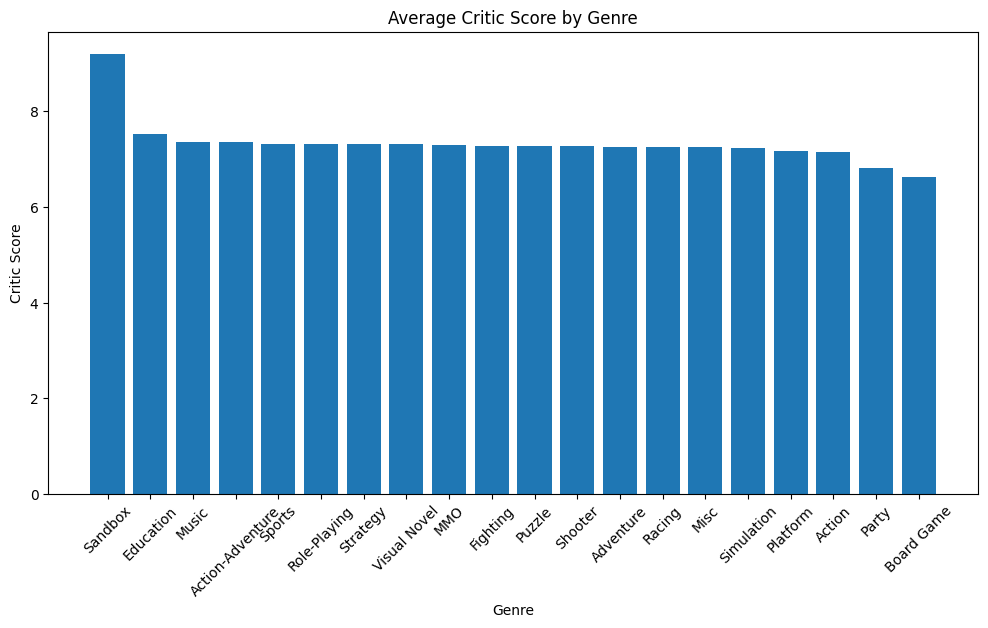

In [123]:
# 11. Average Critic Score by Genre
genre_score = df.groupby("genre")["critic_score"].mean().sort_values(ascending=False)

plt.figure(figsize=(12,6))
plt.bar(genre_score.index, genre_score.values)
plt.xticks(rotation=45)
plt.title("Average Critic Score by Genre")
plt.xlabel("Genre")
plt.ylabel("Critic Score")
plt.show()


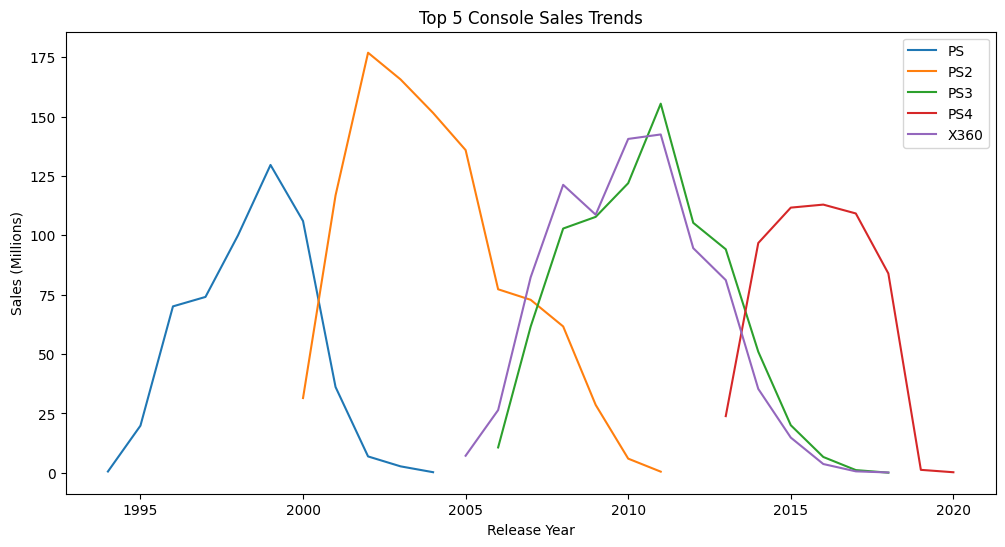

In [125]:
# 12. Console Popularity Over Time (Top 5 Consoles)
top5_consoles = df.groupby("console")["total_sales_of_copies_in_millions"].sum().sort_values(ascending=False).head(5).index
console_trend = df[df["console"].isin(top5_consoles)].groupby(["release_year", "console"])["total_sales_of_copies_in_millions"].sum().unstack()

plt.figure(figsize=(12,6))
for col in console_trend.columns:
    plt.plot(console_trend.index, console_trend[col], label=col)

plt.title("Top 5 Console Sales Trends")
plt.xlabel("Release Year")
plt.ylabel("Sales (Millions)")
plt.legend()
plt.show()

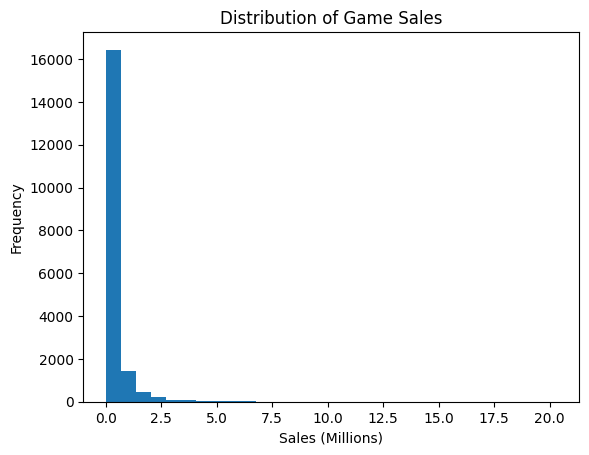

In [126]:
# 13. Distribution of Sales
plt.figure()
plt.hist(df["total_sales_of_copies_in_millions"], bins=30)
plt.title("Distribution of Game Sales")
plt.xlabel("Sales (Millions)")
plt.ylabel("Frequency")
plt.show()

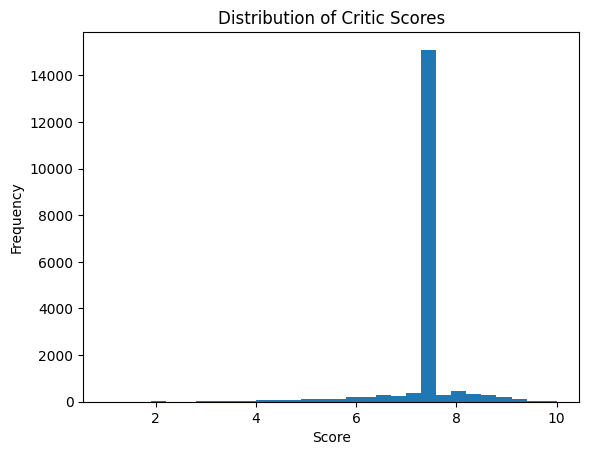

In [127]:
# 14. Distribution of Critic Scores
plt.figure()
plt.hist(df["critic_score"], bins=30)
plt.title("Distribution of Critic Scores")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.show()

In [128]:
# 15. Correlation Analysis
numeric_df = df[["critic_score", "total_sales_of_copies_in_millions", "release_year"]]
corr = numeric_df.corr()
print("\nCorrelation Matrix:\n", corr)


Correlation Matrix:
                                    critic_score  \
critic_score                           1.000000   
total_sales_of_copies_in_millions      0.196856   
release_year                           0.019978   

                                   total_sales_of_copies_in_millions  \
critic_score                                                0.196856   
total_sales_of_copies_in_millions                           1.000000   
release_year                                               -0.038600   

                                   release_year  
critic_score                           0.019978  
total_sales_of_copies_in_millions     -0.038600  
release_year                           1.000000  


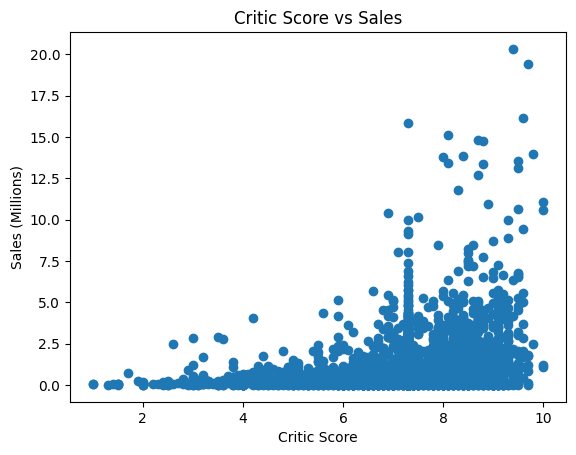

In [129]:
# 16. Critic Score vs Sales Scatter Plot
plt.figure()
plt.scatter(df["critic_score"], df["total_sales_of_copies_in_millions"])
plt.title("Critic Score vs Sales")
plt.xlabel("Critic Score")
plt.ylabel("Sales (Millions)")
plt.show()

In [130]:

# 17. Top Game Each Year
top_per_year = df.loc[df.groupby("release_year")["total_sales_of_copies_in_millions"].idxmax()]
print("\nTop Game Each Year:\n", top_per_year[["release_year", "title", "total_sales_of_copies_in_millions"]])


Top Game Each Year:
       release_year                                              title  \
1101        1977.0                                             Combat   
3652        1978.0                                       Circus Atari   
5171        1979.0                                       Slot Machine   
2058        1980.0                                             Boxing   
125         1981.0                                          Asteroids   
467         1982.0                                       Demon Attack   
718         1983.0                                            Dig Dug   
2036        1984.0                                        Jr. Pac-Man   
1917        1985.0                                       Clu Clu Land   
814         1986.0  Ninja Hattori Kun: Ninja wa Shuugyou Degogiru ...   
1086        1987.0      Gegege no Kitarou 2: Youkai Gundan no Chousen   
445         1988.0                                    R.B.I. Baseball   
135         1989.0           

In [131]:
# 18. Genre vs Console Pivot Table
pivot = pd.pivot_table(
    df,
    values="total_sales_of_copies_in_millions",
    index="genre",
    columns="console",
    aggfunc="sum"
).fillna(0)

print("\nGenre vs Console Pivot Table:\n", pivot.head())



Genre vs Console Pivot Table:
 console            2600   3DO    3DS    DC     DS    GB    GBA   GBC     GC  \
genre                                                                         
Action            28.93  0.00  16.57  0.12  65.24  1.86  41.53  0.00  18.67   
Action-Adventure   0.00  0.00   7.52  0.00   0.95  0.00   0.00  0.00   0.00   
Adventure          0.00  0.06   5.06  1.32  64.25  0.52  19.55  3.78   7.66   
Board Game         0.00  0.00   0.00  0.00   0.00  0.00   0.00  0.00   0.00   
Education          0.00  0.00   0.09  0.00   0.00  0.00   0.00  0.00   0.12   

console            GEN  ...  SNES   VC   WS   WW    Wii  WiiU    X360     XB  \
genre                   ...                                                    
Action            4.15  ...  0.77  0.0  0.0  0.0  63.12  5.49  161.89  41.80   
Action-Adventure  0.00  ...  0.00  0.0  0.0  0.0   2.90  7.13   24.59   0.71   
Adventure         0.19  ...  1.50  0.0  0.0  0.0  34.99  0.30   27.69   7.62   
Board Game    

In [132]:
# 19. Best Performing Developer per Year
best_dev_year = df.loc[df.groupby("release_year")["total_sales_of_copies_in_millions"].idxmax()]
print("\nBest Developer Each Year:\n", best_dev_year[["release_year", "developer", "total_sales_of_copies_in_millions"]])


Best Developer Each Year:
       release_year                    developer  \
1101        1977.0                        Atari   
3652        1978.0                        Atari   
5171        1979.0                        Atari   
2058        1980.0                   Activision   
125         1981.0                        Atari   
467         1982.0                       Imagic   
718         1983.0                        Atari   
2036        1984.0        General Entertainment   
1917        1985.0                Nintendo R&D1   
814         1986.0                  Hudson Soft   
1086        1987.0                       Bandai   
445         1988.0                        Namco   
135         1989.0                       Konami   
339         1990.0                         Sega   
1187        1991.0                        Namco   
923         1992.0                       Konami   
318         1993.0  Probe Entertainment Limited   
181         1994.0                  id Software   
259